In [1]:
#drive connection
#from google.colab import drive
#drive.mount('/content/drive')

# Task 1: Data Understanding and Visualization

In [22]:
#imports
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [23]:
#train dataset path
train_dir = "/content/drive/MyDrive/Ai ML/week5/FruitinAmazon/train"

#list of each directories inside train directory
classes = os.listdir(train_dir)
print("Classes:", classes)


Classes: ['guarana', 'acai', 'graviola', 'cupuacu', 'pupunha', 'tucuma']


In [4]:
images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    images.append((cls, img_path))

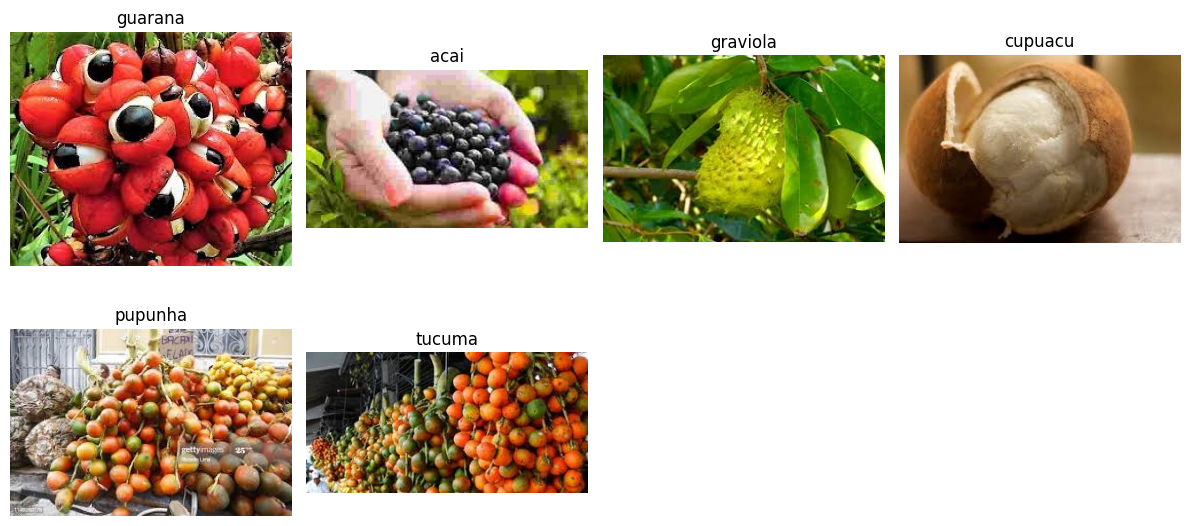

In [5]:
plt.figure(figsize=(12, 6))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

- Data Classes: The dataset contains 6 classes of fruits: 'guarana', 'acai', 'graviola', 'cupuacu', 'pupunha', and 'tucuma'.


- Corrupted Images: No corrupted images were found in the training dataset, which is excellent for model quality.


- Image Preprocessing: Images were resized to 128x128 pixels, normalized by rescaling pixel values to a range of 0-1, and split into training (72 images) and validation (18 images) datasets.


- Model Architecture: A Convolutional Neural Network (CNN) was constructed with two Conv2D and MaxPooling2D layers, followed by Flatten and Dense layers, ending with a softmax activation for classification among the 6 fruit classes.


- Training Performance: The model was trained for multiple epochs, achieving a validation accuracy of approximately 88.89% and a validation loss of around 0.1661.


- Test Performance: On the separate test dataset (30 images), the model achieved a test accuracy of 60% and a test loss of 1.0387. This indicates a notable drop in performance compared to the validation set, suggesting potential overfitting or that the test set is more challenging.


- Classification Report: The classification report for the test data shows varying performance across classes. 'guarana', 'graviola', and 'cupuacu' have relatively good precision and recall. However, 'acai', 'pupunha', and 'tucuma' show lower precision and recall, contributing to the overall lower test accuracy. The macro average for precision, recall, and f1-score is around 0.59-0.60.


In [6]:
#Check for Corrupted Image
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


#Task 2: Loading and Preprocessing Image Data in Keras

In [7]:
#impot and setting vlaue for image data
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [8]:
#convert the pixel value to either 0 or 1.
rescale = tf.keras.layers.Rescaling(1./255)

In [9]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [10]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 & 4: CNN Model

In [11]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#Compile Module
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
#Train the model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.1047 - loss: 1.9369

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - accuracy: 0.1111 - loss: 2.0543 - val_accuracy: 0.8333 - val_loss: 1.2878
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.2083 - loss: 1.8719 - val_accuracy: 0.6111 - val_loss: 1.4984
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.3056 - loss: 1.6164 - val_accuracy: 0.6667 - val_loss: 1.4532
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.2940 - loss: 1.5476

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.3194 - loss: 1.5152 - val_accuracy: 0.7222 - val_loss: 1.2577
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.3536 - loss: 1.4005

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - accuracy: 0.3889 - loss: 1.3634 - val_accuracy: 0.7778 - val_loss: 0.9164
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.4444 - loss: 1.2092 - val_accuracy: 0.6111 - val_loss: 1.1180
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.6944 - loss: 1.0276 - val_accuracy: 0.7778 - val_loss: 1.0490
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7459 - loss: 0.8787

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.7222 - loss: 0.8595 - val_accuracy: 0.8889 - val_loss: 0.6155
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.8194 - loss: 0.6569 - val_accuracy: 0.7778 - val_loss: 0.7400
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step - accuracy: 0.9028 - loss: 0.4329 - val_accuracy: 0.6667 - val_loss: 0.9889
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8443 - loss: 0.4427

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 612ms/step - accuracy: 0.8611 - loss: 0.4015 - val_accuracy: 0.8333 - val_loss: 0.5982
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9398 - loss: 0.2832

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - accuracy: 0.9444 - loss: 0.2582 - val_accuracy: 0.8333 - val_loss: 0.5235
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.9606 - loss: 0.2453

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.9444 - loss: 0.2758 - val_accuracy: 0.8333 - val_loss: 0.4808
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 357ms/step - accuracy: 0.9861 - loss: 0.1248 - val_accuracy: 0.7222 - val_loss: 0.7640
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - accuracy: 0.9861 - loss: 0.1130 - val_accuracy: 0.7778 - val_loss: 0.5609
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9797 - loss: 0.0694

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 0.9861 - loss: 0.0636 - val_accuracy: 0.8889 - val_loss: 0.1661
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.9861 - loss: 0.0605 - val_accuracy: 0.8333 - val_loss: 0.4635
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 555ms/step - accuracy: 1.0000 - loss: 0.0332 - val_accuracy: 0.8333 - val_loss: 0.7542
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 1.0000 - loss: 0.0204 - val_accuracy: 0.8333 - val_loss: 0.6154
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 0.8333 - val_loss: 0.4795
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 0.8889 - val_loss: 0.3361
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 354ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.8889 - val_loss: 0.2986
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.8889 - val_lo

In [14]:
#Evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8889 - loss: 0.1661
Test Loss: 0.16610577702522278
Test Accuracy: 0.8888888955116272


In [15]:
#Save the Model
model.save("week5_cnn_model.h5")

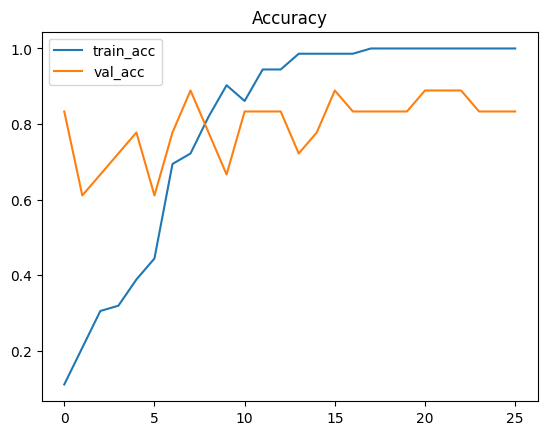

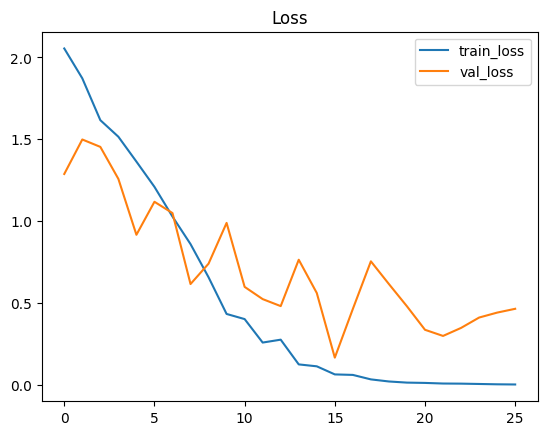

In [16]:
#Visualization of taining and validation loss and accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

The images displayed provide a visual overview of the dataset by showcasing a single, randomly selected example from each of the six fruit classes: 'guarana', 'acai', 'graviola', 'cupuacu', 'pupunha', and 'tucuma'. This visualization is a crucial step in data understanding, allowing for a quick inspection of the variety, resolution, and general characteristics of the images within each category. It helps to confirm that the images are correctly labeled and provides a preliminary sense of the visual distinctions and similarities between the different fruit types.

From a model training perspective, observing these representative images can offer insights into the classification challenges. For instance, some fruits might have distinct features making them easy to differentiate, while others might share similar colors, shapes, or textures, potentially leading to confusion for the model. Factors like varying lighting conditions, backgrounds, or angles captured in these sample images also hint at the diversity within each class that the model needs to learn to generalize effectively. This initial visual assessment often guides decisions on preprocessing techniques, augmentation strategies, or potential model architectural choices to handle the specific characteristics of the dataset.

# Task 7: Predictions and Classification Report

In [18]:
#Test Data
test_dir = "/content/drive/MyDrive/Ai ML/week5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

#normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [19]:
#loss and accuracy on test data
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.6000 - loss: 1.0387
Test Loss: 1.0387
Test Accuracy: 0.6000


In [20]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

     guarana       0.80      0.80      0.80         5
        acai       0.43      0.60      0.50         5
    graviola       0.67      0.80      0.73         5
     cupuacu       0.67      0.80      0.73         5
     pupunha       0.50      0.20      0.29         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.60        30
   macro avg       0.59      0.60      0.58        30
weighted avg       0.59      0.60      0.58        30



The model's evaluation on the independent test dataset revealed a significant divergence in performance when compared to the validation set. Specifically, the test accuracy dropped to 60%, accompanied by an increased test loss of 1.0387. This notable degradation suggests that the model might be overfitting to the training data, capturing noise or specific patterns in the training set that do not generalize well to unseen examples. Further analysis through the classification report illuminated the nuanced performance across different fruit classes. While the model demonstrated relatively strong predictive capabilities for 'guarana', 'graviola', and 'cupuacu', evidenced by their comparatively high precision and recall scores, it struggled considerably with other classes such as 'acai', 'pupunha', and 'tucuma'. For these challenging categories, the precision and recall values were noticeably lower, indicating a higher rate of misclassification. The aggregated macro average for precision, recall, and f1-score, hovering around 0.59-0.60, corroborates this uneven performance. This detailed breakdown highlights critical areas where the model could be improved, potentially through regularization techniques, data augmentation, or addressing any inherent class imbalance that might be contributing to the poorer performance on specific fruit types.